# Lab 4.01 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 1 - soft-drinks


The file softdrinks.xlsx categorizes 250 randomly
selected consumers on the basis of their gender, their
age, and their preference for our brand or a competitor's brand of a low-calorie soft drink. Use a chi-square test for independence to see whether the drink
preference is independent of gender, and then whether
it is independent of age.  First make a plot

Results of the main calculations:
- age vs preference
  - χ² ≈ 3.8589  
  - p-value = 0.2771
  - We do not reject H0


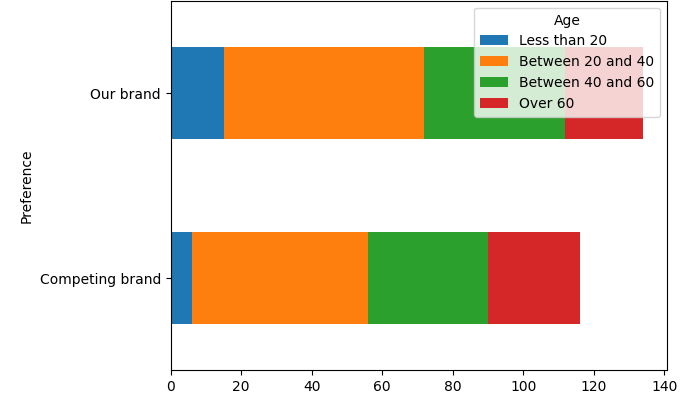



- gender vs preference
  - χ² ≈ 1.4078
  - p-value = 0.2354
  - We do not reject H0

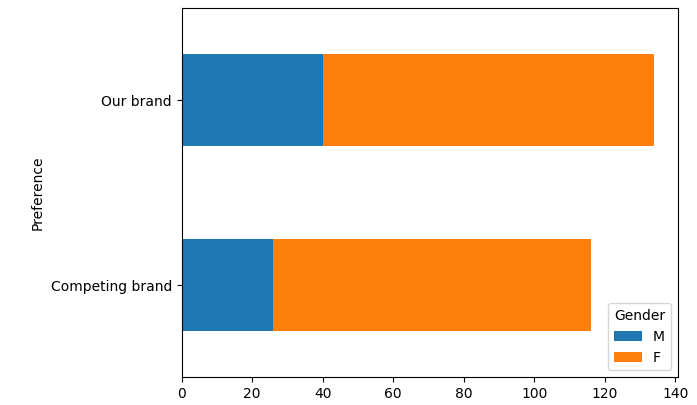

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Softdrinks.csv', sep=";")
df.head()

,Consumer,Gender,Age,Preference
0,1,F,Over 60,Our brand
1,2,F,Between 40 and 60,Our brand
2,3,M,Between 40 and 60,Our brand
3,4,F,Over 60,Competing brand
4,5,M,Between 20 and 40,Our brand


### Age vs Brand

In [4]:
df.groupby('Age')['Preference'].value_counts()

Age                Preference     
Between 20 and 40  Our brand          57
                   Competing brand    50
Between 40 and 60  Our brand          40
                   Competing brand    34
Less than 20       Our brand          15
                   Competing brand     6
Over 60            Competing brand    26
                   Our brand          22
Name: count, dtype: int64

### Gender vs Brand

In [9]:
gender_pref= pd.crosstab(df['Gender'], df['Preference'])
gender_pref

Preference,Competing brand,Our brand
Gender,,
F,90,94
M,26,40


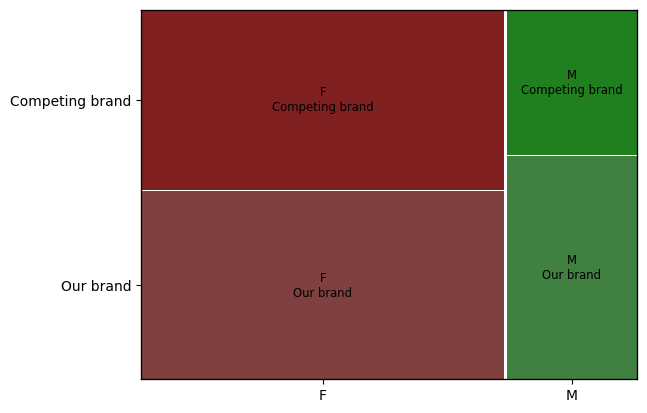

In [14]:
mosaic(data=df,index=['Gender','Preference']);

In [16]:
 chi2,p,df2,expected = stats.chi2_contingency(gender_pref)
 chi2,p,df2,expected

(np.float64(1.4077735237706785),
 np.float64(0.23542635283778704),
 1,
 array([[85.376, 98.624],
        [30.624, 35.376]]))

In [17]:
stats.contingency.association(gender_pref, method='cramer')

0.0841386541667046